# Spam Email Detection

## 06. Final Model Evaluation

The tuned Logistic Regression pipeline is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

The final trained pipeline is saved as a `.joblib` model for deployment.

In [2]:
## output

from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent.parent

# Dataset
DATA_DIR = BASE_DIR / "data"

# Outputs
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

# Models
MODEL_DIR = BASE_DIR / "models"

# Create folders
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "email.csv"

print("PROJECT:", BASE_DIR)
print("DATASET:", DATA_PATH)
print("FIGURES:", FIGURE_DIR)
print("RESULTS:", RESULT_DIR)
print("MODELS:", MODEL_DIR)

PROJECT: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection
DATASET: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\data\email.csv
FIGURES: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\figures
RESULTS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\outputs\results
MODELS: c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\models


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import joblib

In [4]:
BASE_DIR = Path.cwd().parent.parent

DATA_PATH = BASE_DIR / "data" / "email.csv"

OUTPUT_DIR = BASE_DIR / "outputs"

FIGURE_DIR = OUTPUT_DIR / "figures"

RESULT_DIR = OUTPUT_DIR / "results"

MODEL_DIR = BASE_DIR / "models"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

df["Category"] = df["Category"].astype(str).str.strip().str.lower()

df = df[
    df["Category"].isin(["ham", "spam"])
].copy()

df["Message"] = df["Message"].astype(str)

df = df.drop_duplicates()

df["label"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})

X = df["Message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
final_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english"
        )
    ),

    (
        "select",
        SelectKBest(
            chi2
        )
    ),

    (
        "model",
        LogisticRegression(
            max_iter=2500,
            random_state=42
        )
    )
])

In [6]:
param_grid = {

    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2
    ],

    "select__k": [
        1000,
        2000,
        3000
    ],

    "model__C": [
        0.5,
        1.0,
        2.0
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = GridSearchCV(
    final_pipeline,
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

best_model = search.best_estimator_

print("Final model trained successfully!")
print("Best parameters:")
print(search.best_params_)

Final model trained successfully!
Best parameters:
{'model__C': 2.0, 'model__class_weight': 'balanced', 'select__k': 2000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}


In [7]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

y_pred = best_model.predict(X_test)

y_probability = best_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["ham", "spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       904
        spam       0.90      0.89      0.90       128

    accuracy                           0.97      1032
   macro avg       0.94      0.94      0.94      1032
weighted avg       0.97      0.97      0.97      1032



In [8]:
# ============================================================
# FINAL EVALUATION METRICS
# ============================================================

final_metrics = pd.DataFrame([{
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),
    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "F1_Score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_probability
    )
}])

final_metrics.to_csv(
    RESULT_DIR / "17_final_model_metrics.csv",
    index=False
)

final_metrics

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Tuned Logistic Regression,0.974806,0.904762,0.890625,0.897638,0.990537


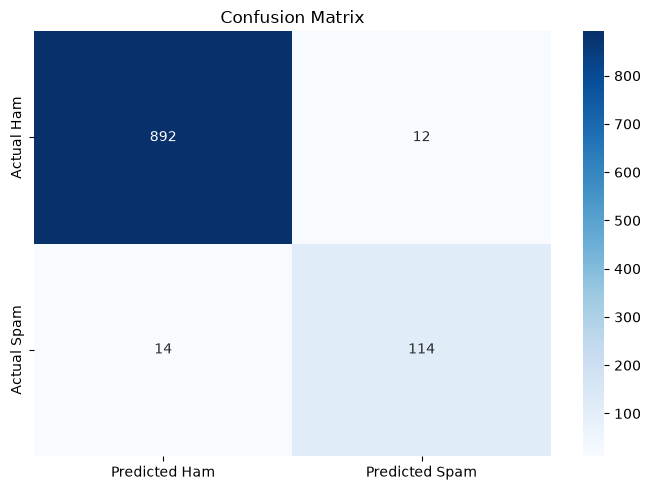

In [9]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Ham", "Actual Spam"],
    columns=["Predicted Ham", "Predicted Spam"]
)

cm_df.to_csv(
    RESULT_DIR / "18_confusion_matrix.csv"
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "08_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

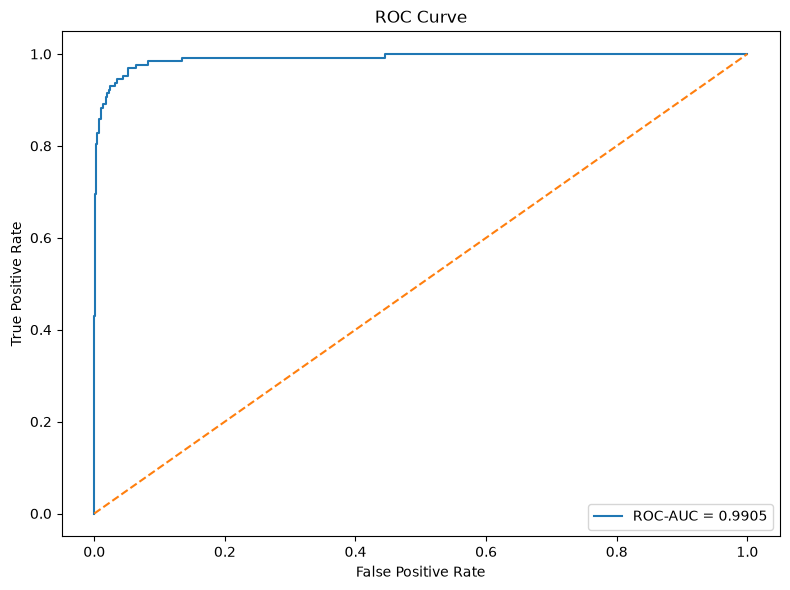

In [10]:
# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_value = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc_value:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "09_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

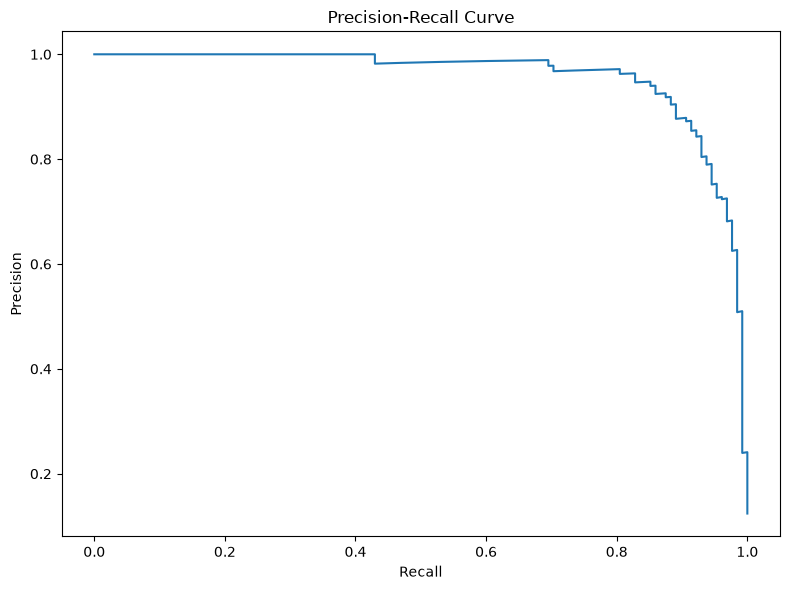

In [11]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "10_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

model_path = (
    MODEL_DIR /
    "spam_email_tfidf_logistic_regression.joblib"
)

joblib.dump(
    best_model,
    model_path
)

print("Final model saved successfully!")
print(model_path)

Final model saved successfully!
c:\Users\HP\OneDrive\Desktop\Spam-Email-Detection\models\spam_email_tfidf_logistic_regression.joblib


In [13]:
# ============================================================
# SAMPLE DEPLOYMENT PREDICTION
# ============================================================

def predict_message(message):

    prediction = best_model.predict(
        [message]
    )[0]

    probability = best_model.predict_proba(
        [message]
    )[0][1]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    return result, probability


sample_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hi, are we meeting for lunch today?"
]

prediction_results = []

for message in sample_messages:

    result, probability = predict_message(
        message
    )

    prediction_results.append({
        "Message": message,
        "Prediction": result,
        "Spam_Probability": probability
    })

prediction_df = pd.DataFrame(
    prediction_results
)

prediction_df.to_csv(
    RESULT_DIR / "19_sample_predictions.csv",
    index=False
)

prediction_df

,Message,Prediction,Spam_Probability
0,Congratulations! You have won a free prize. Ca...,SPAM,0.95820
1,"Hi, are we meeting for lunch today?",HAM,0.03244
